In [11]:
import gymnasium as gym
from policy import MonteCarlo, PolicyIteration
from envs.register import register_envs
register_envs()

env = gym.make("WindyRooms-v1")
policy, V = PolicyIteration(env)
returns = MonteCarlo(env, policy)

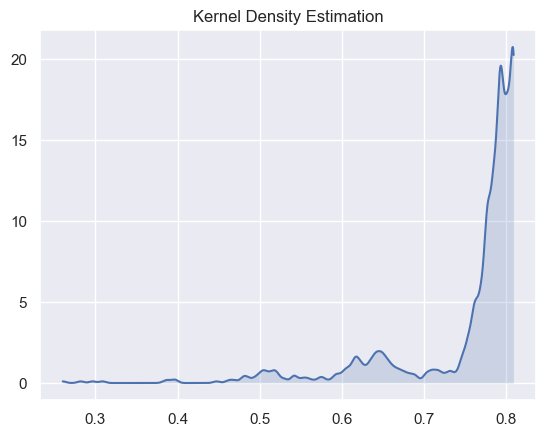

In [12]:
from analysis import plot_returns
plot_returns(returns, bandwith=0.004)

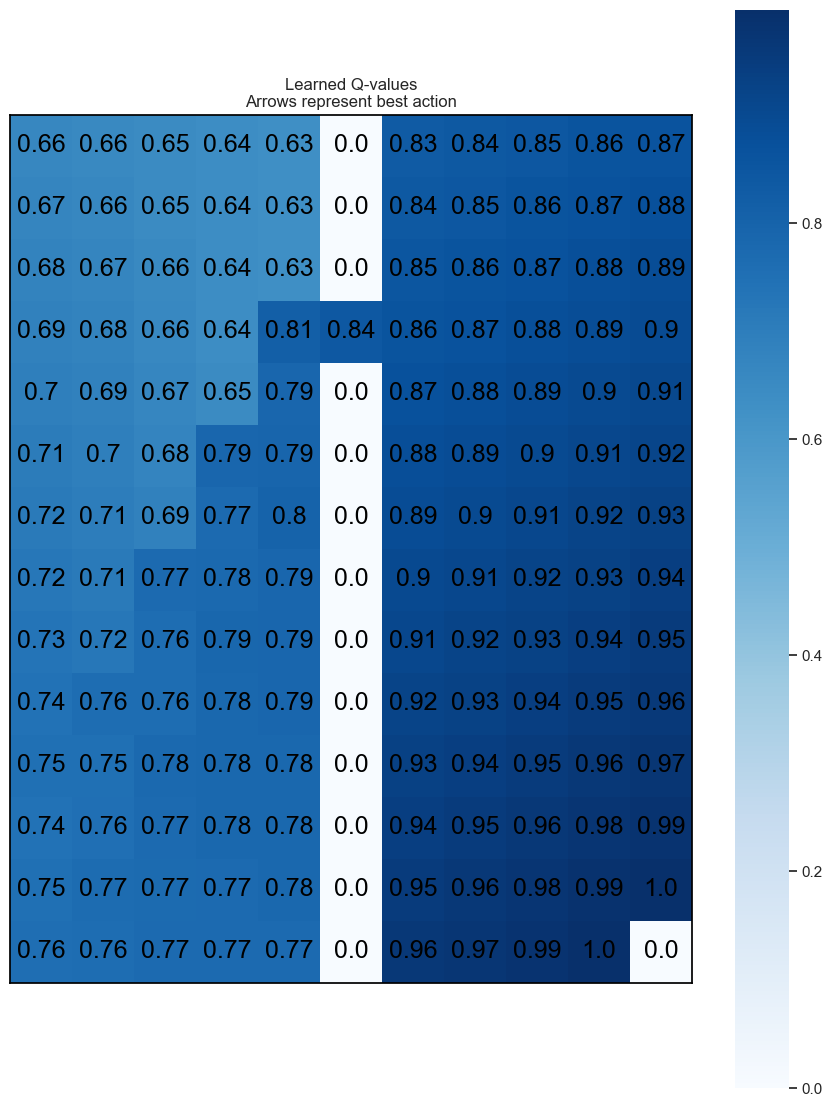

In [16]:
from matplotlib import pyplot as plt
import seaborn as sns

map_size = (14,11)
fig, ax = plt.subplots(figsize=(map_size[1], map_size[0]))

arrow_directions = {0: "↑", 1: "→", 2: "↓", 3: "←"}
policy_arrows = np.array([arrow_directions[a] for a in policy]).reshape((14,11))

heatmap = sns.heatmap(
    V.reshape((14,11)),
    annot=V.reshape((14,11)).round(2),
    # annot=policy_arrows,
    fmt="",
    ax=ax,
    cmap=sns.color_palette("Blues", as_cmap=True),
    linecolor="black",
    xticklabels=[],
    yticklabels=[],
    annot_kws={"fontsize": "18", "color": "black"},
    square=True,
)
heatmap.set(title="Learned Q-values\nArrows represent best action")

for _, spine in ax.spines.items():
    spine.set_visible(True)
    spine.set_color("black")

plt.show()